# Sample dataset

In [2]:
data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

# Exercise 1: Exploring Text Preprocessing usage, NER and POS tags

1. Create a function preprocess_text() wich will receive the data as argument and:

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
import string

nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
def preprocess_text(text):
  # 1. convert all the text in lower case and tokanize it
  text=text.lower()
  tokens=nltk.word_tokenize(text)
  # 2. remove punctuation
  tokens=[word for word in tokens if word not in string.punctuation]
  # 3. apply a lemmatizer
  lemmatizer=WordNetLemmatizer()
  tokens=[lemmatizer.lemmatize(word) for word in tokens]
  return tokens

In [5]:
for review in data['Review']:
  print(preprocess_text(review))

['at', 'mcdonald', "'s", 'the', 'food', 'wa', 'ok', 'and', 'the', 'service', 'wa', 'bad']
['i', 'would', 'not', 'recommend', 'this', 'japanese', 'restaurant', 'to', 'anyone']
['i', 'loved', 'this', 'restaurant', 'when', 'i', 'traveled', 'to', 'thailand', 'last', 'summer']
['the', 'menu', 'of', 'loving', 'ha', 'a', 'wide', 'variety', 'of', 'option']
['the', 'staff', 'wa', 'friendly', 'and', 'helpful', 'at', 'google', "'s", 'employee', 'restaurant']
['the', 'ambiance', 'at', 'bella', 'italia', 'is', 'amazing', 'and', 'the', 'pasta', 'dish', 'are', 'delicious']
['i', 'had', 'a', 'terrible', 'experience', 'at', 'pizza', 'hut', 'the', 'pizza', 'wa', 'burnt', 'and', 'the', 'service', 'wa', 'slow']
['the', 'sushi', 'at', 'sushi', 'express', 'is', 'always', 'fresh', 'and', 'flavorful']
['the', 'steakhouse', 'on', 'main', 'street', 'ha', 'a', 'cozy', 'atmosphere', 'and', 'excellent', 'steak']
['the', 'dessert', 'selection', 'at', 'sweet', 'treat', 'is', 'to', 'die', 'for']


2. Create a new dataset with the cleaned text

In [6]:
cleaned_data = {'Cleaned Review': []}
for review in data['Review']:
  cleaned_data['Cleaned Review'].append(preprocess_text(review))
print(cleaned_data)

{'Cleaned Review': [['at', 'mcdonald', "'s", 'the', 'food', 'wa', 'ok', 'and', 'the', 'service', 'wa', 'bad'], ['i', 'would', 'not', 'recommend', 'this', 'japanese', 'restaurant', 'to', 'anyone'], ['i', 'loved', 'this', 'restaurant', 'when', 'i', 'traveled', 'to', 'thailand', 'last', 'summer'], ['the', 'menu', 'of', 'loving', 'ha', 'a', 'wide', 'variety', 'of', 'option'], ['the', 'staff', 'wa', 'friendly', 'and', 'helpful', 'at', 'google', "'s", 'employee', 'restaurant'], ['the', 'ambiance', 'at', 'bella', 'italia', 'is', 'amazing', 'and', 'the', 'pasta', 'dish', 'are', 'delicious'], ['i', 'had', 'a', 'terrible', 'experience', 'at', 'pizza', 'hut', 'the', 'pizza', 'wa', 'burnt', 'and', 'the', 'service', 'wa', 'slow'], ['the', 'sushi', 'at', 'sushi', 'express', 'is', 'always', 'fresh', 'and', 'flavorful'], ['the', 'steakhouse', 'on', 'main', 'street', 'ha', 'a', 'cozy', 'atmosphere', 'and', 'excellent', 'steak'], ['the', 'dessert', 'selection', 'at', 'sweet', 'treat', 'is', 'to', 'die',

3. Create a function perform_ner() that will receive the text as argument and perform NER tagging on it. Use spacy en_core_web_sm

In [7]:
import spacy
nlp=spacy.load('en_core_web_sm')

In [8]:
def perform_ner(text):
  doc=nlp(text)
  entities = [(entity.text, entity.label_) for entity in doc.ents]
  return entities

In [9]:
for review in cleaned_data['Cleaned Review']:
  for word in review:
    if perform_ner(word):
      print(perform_ner(word))

[('japanese', 'NORP')]
[('thailand', 'GPE')]
[('summer', 'DATE')]
[('dessert', 'PERSON')]


4. Create a function perform_pos_tagging() that will receive the text as argument and perform POS tagging on it.

In [10]:
def perform_pos_tagging(text):
  doc=nlp(text)
  pos_tags = [(token.text, token.pos_) for token in doc]
  return pos_tags

In [11]:
for review in cleaned_data['Cleaned Review']:
  for word in review:
    if perform_pos_tagging(word):
      print(perform_pos_tagging(word))

[('at', 'ADP')]
[('mcdonald', 'NOUN')]
[("'s", 'AUX')]
[('the', 'PRON')]
[('food', 'NOUN')]
[('wa', 'INTJ')]
[('ok', 'INTJ')]
[('and', 'CCONJ')]
[('the', 'PRON')]
[('service', 'NOUN')]
[('wa', 'INTJ')]
[('bad', 'ADJ')]
[('i', 'PRON')]
[('would', 'AUX')]
[('not', 'PART')]
[('recommend', 'VERB')]
[('this', 'PRON')]
[('japanese', 'NOUN')]
[('restaurant', 'NOUN')]
[('to', 'PART')]
[('anyone', 'PRON')]
[('i', 'PRON')]
[('loved', 'VERB')]
[('this', 'PRON')]
[('restaurant', 'NOUN')]
[('when', 'SCONJ')]
[('i', 'PRON')]
[('traveled', 'VERB')]
[('to', 'PART')]
[('thailand', 'PROPN')]
[('last', 'ADJ')]
[('summer', 'NOUN')]
[('the', 'PRON')]
[('menu', 'NOUN')]
[('of', 'ADP')]
[('loving', 'VERB')]
[('ha', 'INTJ')]
[('a', 'PRON')]
[('wide', 'ADV')]
[('variety', 'NOUN')]
[('of', 'ADP')]
[('option', 'NOUN')]
[('the', 'PRON')]
[('staff', 'NOUN')]
[('wa', 'INTJ')]
[('friendly', 'ADJ')]
[('and', 'CCONJ')]
[('helpful', 'ADJ')]
[('at', 'ADP')]
[('google', 'PROPN')]
[("'s", 'AUX')]
[('employee', 'NOUN')]
[(

In [12]:
nltk.download('tagsets')
nltk.help.upenn_tagset('NN')

NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...


[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.


In [13]:
nltk.help.upenn_tagset('PRON')

No matching tags found.


# Exercise 2: Plotting the word embeddings

1. Create the word embeddings using Word2Vec model to vectorize the text.

In [14]:
from gensim.models import Word2Vec
sentences = cleaned_data['Cleaned Review']
model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, workers=4)
word_embeddings = model.wv
print("Word2Vec Vocabulary Size:", len(word_embeddings.key_to_index))
print("Word2Vec Vector Dimensions:", word_embeddings.vector_size)

Word2Vec Vocabulary Size: 73
Word2Vec Vector Dimensions: 100


Explanation:
  * vector_dim = model.vector_size: The vector_size (or size in older versions of Gensim) attribute of the Word2Vec model gives you the number of dimensions in which each word vector is represented. This is usually specified when you train the model (e.g., vector_size=100).
  * vocab_size = len(model.wv): This gives you the number of words in the model’s vocabulary.

Analysis:

* Vector Dimensions:
  * The vector dimensions, often denoted as vector_size or dim, represent the number of features or components in the vector space. A common choice is 100, 200, or 300 dimensions, though this can vary.
  * What It Means: Each word is represented as a point in this high-dimensional space. The dimensions are abstract and don't directly correspond to specific word features like "gender" or "tense." Instead, they are learned features that capture complex relationships and similarities between words. For example, words with similar meanings or that appear in similar contexts will have vectors that are close to each other in this space.
* Vocabulary Size:
  * This tells you how many unique words are in the model’s vocabulary. The vocabulary size is influenced by parameters such as min_count, which specifies the minimum number of occurrences a word must have to be included in the vocabulary.

Interpretation:
  * 100 Dimensions: Each word is represented as a 100-dimensional vector, meaning that the model has learned to represent words in a 100-dimensional space where each dimension captures some aspect of word meaning or context.
  * 5000 Vocabulary Size: The model has learned word vectors for 5000 unique words. These words are the most frequent in your training data (assuming you used min_count=1 to include all words).

In summary, the vector dimensions indicate how rich or detailed the word representations are. Higher dimensions can capture more nuanced relationships between words, but they also require more computational resources. The dimensions help in understanding and comparing word similarities in the embedded space.


2. Create a function plot_word_embeddings() that receives the word2vec object as argument and plots the embeddings dimensions in a grided plot. Use a scatter plot. Loop through the words and use annotate() method to add text labels to each point on the scatter plot.

Finally call this function to see the plots and analyse it:
  * Are the related words close to each other?
  * What can be the possible reasons for this output?

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_word_embeddings(model, method='pca', num_words=100):
    # Extract word vectors and corresponding words
    words = list(model.wv.index_to_key)[:num_words]
    word_vectors = [model.wv[word] for word in words]

    # Reduce dimensions to 2D
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=0)
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")

    reduced_vectors = reducer.fit_transform(word_vectors)

    # Create a scatter plot
    plt.figure(figsize=(14, 10))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    # Annotate the points with the word labels
    for i, word in enumerate(words):
        plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]),
                     xytext=(2, 2), textcoords='offset points', ha='right', va='bottom')

    plt.title(f'Word Embeddings ({method.upper()})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.show()

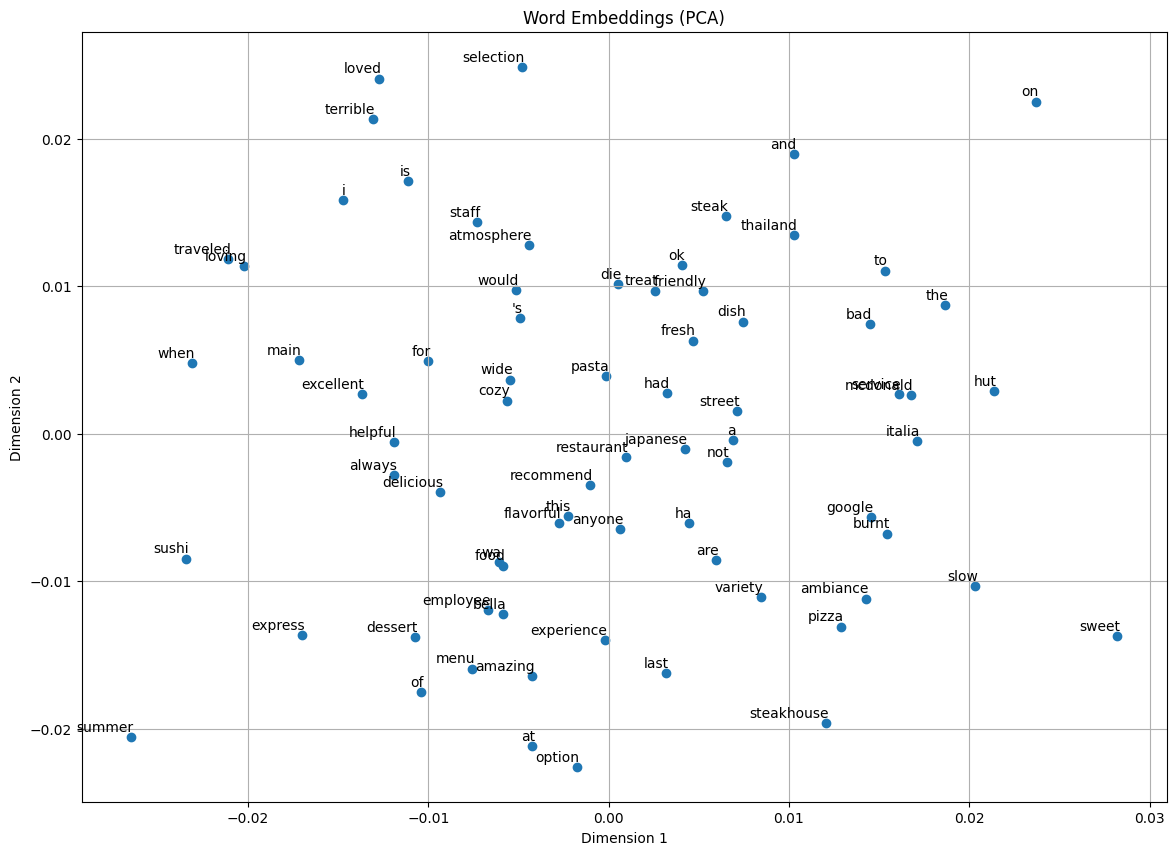

In [16]:
plot_word_embeddings(model)